In [1]:
from bids import BIDSLayout
import nibabel as nb
import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.io as sio
import matplotlib.pyplot as plt
import nibabel as nib

import os
from os.path import join, exists, split
import sys
import time
import urllib.request
import copy
import warnings
from tqdm import tqdm
from pprint import pprint
warnings.filterwarnings('ignore')

import glmsingle
from glmsingle.glmsingle import GLM_single

import nibabel as nib 
from nilearn.glm.first_level import compute_regressor 
from nilearn.glm.first_level import make_first_level_design_matrix 
%matplotlib inline 
import matplotlib.pyplot as plt 

import os

In [4]:
db = BIDSLayout(root="/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/", database_path='/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/bids_layout/')

tmp_files = db.get(
        task='twostep',
        suffix="events",
        extension="tsv",
        return_type="filename"
    )

participants = [i.split('/')[-4].split('-')[-1] for i in tmp_files]

space_name = "MNI152NLin2009cAsym"
task = 'hcp'


def get_subject_data(pidx):

    d = {}

    events_files = db.get(
        task=task,
        suffix="events",
        extension="tsv",
        return_type="filename",
        subject=participants[pidx]
    )

    d["event_files"] = events_files

    bold_files = db.get(
        task=task,
        suffix="bold",
        space=space_name,
        extension="nii.gz",
        return_type="filename",
        res="02",
        subject=participants[pidx]
    )

    d["bold_files"] = bold_files

    tr=db.get(
        task=task,
        suffix="bold",
        space=space_name,
        extension="nii.gz",
        res=None,
        subject=participants[pidx]
    )[0].get_metadata()['RepetitionTime']

    d["tr"] = tr

    n_frames = nb.load(bold_files[0]).shape[-1]
    frame_times = np.arange(n_frames) * tr + tr /2

    d["n_frames"] = n_frames
    d["frame_times"] = frame_times

    return d


#subject_data = [get_subject_data(idx) for idx in range(len(participants))]
subject_data = [get_subject_data(idx) for idx in range(2)]
fmri_file = nib.load(subject_data[0]["bold_files"][0])

In [7]:
subject_data[0]["bold_files"]

['/mnt/projects/rewardMap/STUDIES/pilotstudy/derivatives/fmriprep-25.0.0/sub-rwm001/ses-01/func/sub-rwm001_ses-01_task-hcp_acq-te14ipat2mb2me3pf78_dir-AP_run-02_part-mag_space-MNI152NLin2009cAsym_res-02_desc-preproc_bold.nii.gz']

In [3]:
def make_des_mats(subject):
    frame_times = subject["frame_times"]
    #print(frame_times)
    
    events = pd.read_table(subject["event_files"][0])
    events.loc[pd.isna(events["duration"]), "duration"] = 0
    reward_onsets = events[events["event_type"] == "reward"]["onset"]

    dm = np.zeros((len(frame_times), 1))

    for i, onset in enumerate(reward_onsets):
        idx = (np.abs(frame_times - onset)).argmin()
        dm[idx, 0] = 1

    return dm

for subject in subject_data:
    subject["design_matrices"] = make_des_mats(subject)

<Axes: label='conditions', ylabel='scan number'>

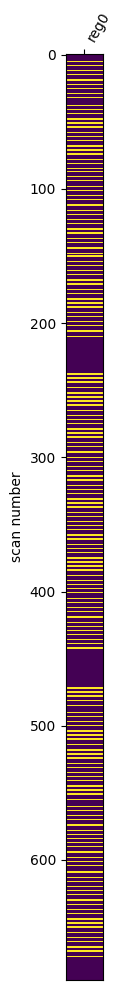

In [4]:
import pandas as pd
from nilearn.plotting import plot_design_matrix

# Suppose you know the regressor names and frame times
design_matrix_array = subject_data[0]["design_matrices"]
regressor_names = [f"reg{i}" for i in range(design_matrix_array.shape[1])]  # or actual names if available
frame_times = range(design_matrix_array.shape[0])

# Convert to DataFrame
design_matrix_df = pd.DataFrame(design_matrix_array, columns=regressor_names, index=frame_times)

# Plot
plot_design_matrix(design_matrix_df)

In [5]:
homedir = split(os.getcwd())[0]

datadir = join(homedir,'examples','data')
os.makedirs(datadir,exist_ok=True)

outputdir_glmsingle = join(homedir,'examples','example1outputs','GLMsingle')

opt = dict()

# set important fields for completeness (but these would be enabled by default)
opt['wantlibrary'] = 1
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 1

# for the purpose of this example we will keep the relevant outputs in memory
# and also save them to the disk
opt['wantfileoutputs'] = [1,1,1,1]
opt['wantmemoryoutputs'] = [1,1,1,1]

# running python GLMsingle involves creating a GLM_single object
# and then running the procedure using the .fit() routine
glmsingle_obj = GLM_single(opt)

# visualize all the hyperparameters
pprint(glmsingle_obj.params)

{'R2thresh': 0,
 'brainR2': [],
 'brainexclude': False,
 'brainthresh': [99.0, 0.1],
 'chunklen': 50000,
 'extra_regressors': False,
 'firdelay': 30,
 'firpct': 99,
 'fracs': array([1.  , 0.95, 0.9 , 0.85, 0.8 , 0.75, 0.7 , 0.65, 0.6 , 0.55, 0.5 ,
       0.45, 0.4 , 0.35, 0.3 , 0.25, 0.2 , 0.15, 0.1 , 0.05]),
 'hrffitmask': 1,
 'hrfmodel': 'optimise',
 'hrfthresh': 0.5,
 'lambda': 0,
 'n_boots': 100,
 'n_jobs': 1,
 'n_pcs': 10,
 'numforhrf': 50,
 'pcR2cutoff': [],
 'pcR2cutoffmask': 1,
 'pcstop': 1.05,
 'seed': 1761209179.678749,
 'suppressoutput': 0,
 'wantautoscale': 1,
 'wantfileoutputs': [1, 1, 1, 1],
 'wantfracridge': 1,
 'wantglmdenoise': 1,
 'wanthdf5': 0,
 'wantlibrary': 1,
 'wantlss': 0,
 'wantmemoryoutputs': [1, 1, 1, 1],
 'wantparametric': 0,
 'wantpercentbold': 1}


In [12]:
data = []
design = []

print(len(subject_data))

file = nib.load(subject_data[0]["bold_files"][0])
print(f"File size: {os.path.getsize(subject_data[0]['bold_files'][0]) / 1e9:.2f} GB")

data.append(file.get_fdata())
# for subject in subject_data[:2]:
#     data.append(nib.load(subject["bold_files"][0]).get_fdata())
#     design.append(subject["design_matrices"])

# events = pd.read_table(subject["event_files"][0])
# events.loc[pd.isna(events["duration"]), "duration"] = 0
# reward_events = events[events["event_type"] == "reward"] 

# stimdur = reward_events["duration"].iloc[0]
# tr = subject_data[0]["tr"]

# pprint(data[0])
# print(f'There are {len(data)} runs in total\n')
# print(f'N = {data[0].shape[3]} TRs per run\n')
# print(f'The dimensions of the data for each run are: {data[0].shape}\n')
# print(f'The stimulus duration is {stimdur} seconds\n')
# print(f'XYZ dimensionality is: {data[0].shape[:3]} (one slice only in this example)\n')

2
File size: 1.86 GB


In [ ]:
print(len(data))

In [ ]:
# create a directory for saving GLMsingle outputs
outputdir_glmsingle = join(homedir,'examples','example1outputs','GLMsingle')

opt = dict()

# set important fields for completeness (but these would be enabled by default)
opt['wantlibrary'] = 1
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 1

# for the purpose of this example we will keep the relevant outputs in memory
# and also save them to the disk
opt['wantfileoutputs'] = [1,1,1,1]
opt['wantmemoryoutputs'] = [1,1,1,1]

# running python GLMsingle involves creating a GLM_single object
# and then running the procedure using the .fit() routine
glmsingle_obj = GLM_single(opt)

# visualize all the hyperparameters
pprint(glmsingle_obj.params)



{'R2thresh': 0,
 'brainR2': [],
 'brainexclude': False,
 'brainthresh': [99.0, 0.1],
 'chunklen': 50000,
 'extra_regressors': False,
 'firdelay': 30,
 'firpct': 99,
 'fracs': array([1.  , 0.95, 0.9 , 0.85, 0.8 , 0.75, 0.7 , 0.65, 0.6 , 0.55, 0.5 ,
       0.45, 0.4 , 0.35, 0.3 , 0.25, 0.2 , 0.15, 0.1 , 0.05]),
 'hrffitmask': 1,
 'hrfmodel': 'optimise',
 'hrfthresh': 0.5,
 'lambda': 0,
 'n_boots': 100,
 'n_jobs': 1,
 'n_pcs': 10,
 'numforhrf': 50,
 'pcR2cutoff': [],
 'pcR2cutoffmask': 1,
 'pcstop': 1.05,
 'seed': 1759405375.7551038,
 'suppressoutput': 0,
 'wantautoscale': 1,
 'wantfileoutputs': [1, 1, 1, 1],
 'wantfracridge': 1,
 'wantglmdenoise': 1,
 'wanthdf5': 0,
 'wantlibrary': 1,
 'wantlss': 0,
 'wantmemoryoutputs': [1, 1, 1, 1],
 'wantparametric': 0,
 'wantpercentbold': 1}


In [ ]:
start_time = time.time()

if not exists(outputdir_glmsingle):

    print(f'running GLMsingle...')
    
    # run GLMsingle
    results_glmsingle = glmsingle_obj.fit(
       design,
       data,
       stimdur,
       tr,
       outputdir=outputdir_glmsingle)
    
    # we assign outputs of GLMsingle to the "results_glmsingle" variable.
    # note that results_glmsingle['typea'] contains GLM estimates from an ONOFF model,
    # where all images are treated as the same condition. these estimates
    # could be potentially used to find cortical areas that respond to
    # visual stimuli. we want to compare beta weights between conditions
    # therefore we are not going to include the ONOFF betas in any analyses of 
    # voxel reliability
    
else:
    print(f'loading existing GLMsingle outputs from directory:\n\t{outputdir_glmsingle}')
    
    # load existing file outputs if they exist
    results_glmsingle = dict()
    results_glmsingle['typea'] = np.load(join(outputdir_glmsingle,'TYPEA_ONOFF.npy'),allow_pickle=True).item()
    results_glmsingle['typeb'] = np.load(join(outputdir_glmsingle,'TYPEB_FITHRF.npy'),allow_pickle=True).item()
    results_glmsingle['typec'] = np.load(join(outputdir_glmsingle,'TYPEC_FITHRF_GLMDENOISE.npy'),allow_pickle=True).item()
    results_glmsingle['typed'] = np.load(join(outputdir_glmsingle,'TYPED_FITHRF_GLMDENOISE_RR.npy'),allow_pickle=True).item()

elapsed_time = time.time() - start_time

print(
    '\telapsed time: ',
    f'{time.strftime("%H:%M:%S", time.gmtime(elapsed_time))}'
)


running GLMsingle...
*** DIAGNOSTICS ***:
There are 2 runs.
The number of conditions in this experiment is 182.
The stimulus duration corresponding to each trial is 1.01 seconds.
The TR (time between successive data points) is 1.80 seconds.
The number of trials in each run is: [179, 181].
The number of trials for each condition is: [np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np

chunks: 100%|██████████| 5/5 [35:54<00:00, 430.84s/it]



*** Saving results to /mnt/scratch/projects/rewardMap/examples/example1outputs/GLMsingle/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 5/5 [2:03:24<00:00, 1480.97s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 5/5 [20:42<00:00, 248.49s/it]



*** Saving results to /mnt/scratch/projects/rewardMap/examples/example1outputs/GLMsingle/TYPEC_FITHRF_GLMDENOISE.npy. ***

*** FITTING TYPE-D MODEL (GLMDENOISE_RR) ***



chunks:   0%|          | 0/5 [54:22<?, ?it/s]


KeyboardInterrupt: 